#Step 1: Import Required Libraries

Before we begin let’s import the necessary libraries: pandas, numpy, tensorflow, matplotlib, wordcloud, nltk for data processing, model building, and visualization

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
import warnings

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)


#Step 2: Load the Dataset
We’ll use a dataset containing labeled emails (Spam or Ham). Let’s load the dataset and inspect its structure.

In [46]:
data = pd.read_csv("spam_ham_dataset.csv")

print("Shape:", data.shape)
data.head()


Shape: (5171, 4)


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


The data contains 5171 rows and four columns.

 # Visualize the label distribution to get understanding of the class distribution

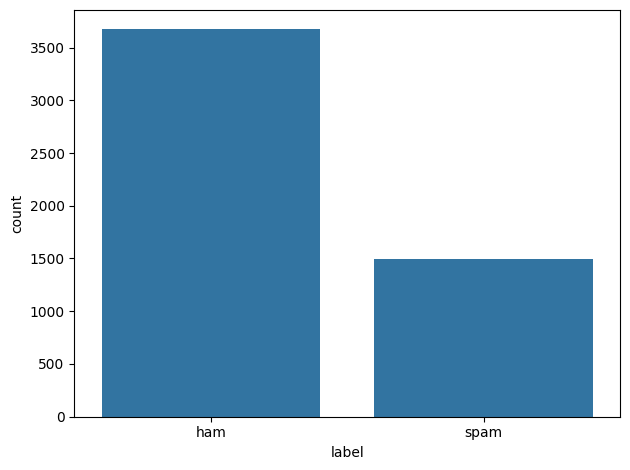

In [47]:
import seaborn as sns

sns.countplot(x="label", data=data)
plt.tight_layout()
plt.show()


# Step 3: Balance the Dataset
We can clearly see that number of samples of Ham is much more than that of Spam which implies that the dataset we are using is imbalanced. To address the imbalance we’ll downsample the majority class (Ham) to match the minority class (Spam)

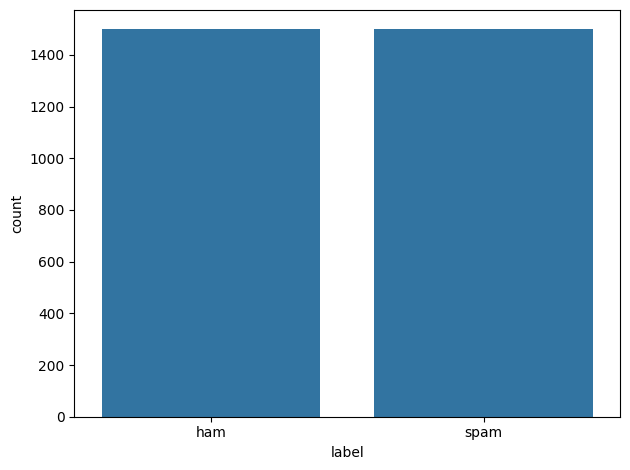

In [48]:
ham_msg = data[data["label"] == "ham"]
spam_msg = data[data["label"] == "spam"]

ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

sns.countplot(x="label", data=balanced_data)
plt.tight_layout()
plt.show()


# Step 4: Clean the Text
Textual data often requires preprocessing before feeding it into a machine learning model. Common steps include removing stopwords, punctuations, and performing stemming/lemmatization.

We’ll perform the following steps:

Stopwords Removal

Punctuations Removal

Stemming or Lemmatization

Although removing data means loss of information we need to do this to make the data perfect to feed into a machine learning model.

In [49]:
balanced_data["text"] = balanced_data["text"].str.replace("Subject", "", regex=False)
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [50]:
import string

translator = str.maketrans("", "", string.punctuation)

balanced_data["text"] = balanced_data["text"].apply(lambda x: x.translate(translator))
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [51]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

balanced_data["text"] = balanced_data["text"].apply(
    lambda x: " ".join(
        word.lower() for word in str(x).split() if word.lower() not in stop_words
    )
)

balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


# Visualization Word Cloud
A word cloud is a text visualization tool that help's us to get insights into the most frequent words present in the corpus of the data.

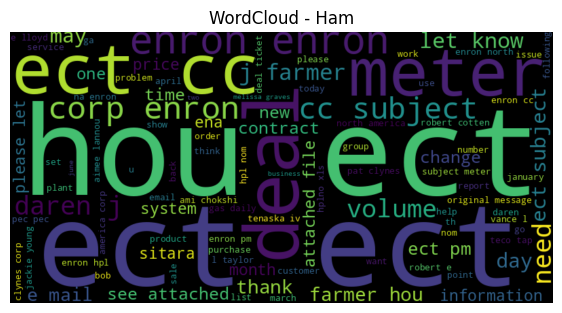

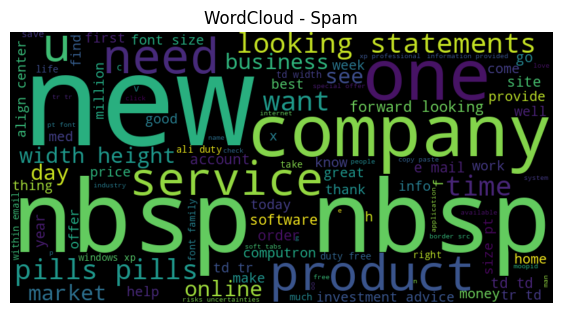

In [52]:
from wordcloud import WordCloud

def plot_word_cloud(df, label):
    text = " ".join(df["text"])
    wc = WordCloud(
        background_color="black",
        max_words=100,
        width=800,
        height=400
    ).generate(text)

    plt.figure(figsize=(7, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"WordCloud - {label}")
    plt.axis("off")
    plt.show()


plot_word_cloud(balanced_data[balanced_data["label"] == "ham"], "Ham")
plot_word_cloud(balanced_data[balanced_data["label"] == "spam"], "Spam")


# step 6: Tokenization and Padding
Machine learning models work with numbers, so we need to convert the text data into numerical vectors using Tokenization and Padding.

Tokenization: Converts each word into a unique integer.
Padding: Ensures that all text sequences have the same length, making them compatible with the model.

In [53]:
# Train-test split
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data["text"],
    balanced_data["label"],
    test_size=0.2,
    random_state=42,
    stratify=balanced_data["label"]
)

# Tokenizer (with OOV handling)
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(train_X)

# Text to sequences
train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

# Padding
MAX_LEN = 100
train_sequences = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post")
test_sequences = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post")

# Label encoding
train_Y = (train_Y == "spam").astype(int)
test_Y = (test_Y == "spam").astype(int)


# Step 7: Define the Model
We will build a deep learning model using a Sequential architecture. This model will include:

Embedding Layer: Learns vector representations of words.
LSTM Layer: Captures patterns in sequences.
Fully Connected Layer: Extracts relevant features.
Output Layer: Predicts whether an email is spam or not

In [54]:
model = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=64,
        input_length=MAX_LEN
    ),
    Bidirectional(LSTM(64)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Step 8: Train the Model
We train the model using EarlyStopping and ReduceLROnPlateau callbacks. These callbacks help stop the training early if the model’s performance doesn’t improve and reduce the learning rate to fine-tune the model.

In [55]:
es = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lr = ReduceLROnPlateau(
    monitor="val_loss",
    patience=2,
    factor=0.5,
    verbose=1
)

history = model.fit(
    train_sequences,
    train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=15,
    batch_size=32,
    callbacks=[es, lr]
)


Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.7506 - loss: 0.5508 - val_accuracy: 0.9583 - val_loss: 0.1312 - learning_rate: 0.0010
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.9708 - loss: 0.0972 - val_accuracy: 0.9733 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.9886 - loss: 0.0404 - val_accuracy: 0.9700 - val_loss: 0.1147 - learning_rate: 0.0010
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.9929 - loss: 0.0276 - val_accuracy: 0.9750 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.9951 - loss: 0.0100 - val_accuracy: 0.9733 - val_loss: 0.1209 - learning_rate: 0.0010
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9971 - loss: 0.0077
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.9972 - loss: 0.007

In [57]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.0714
Test Accuracy: 0.9833


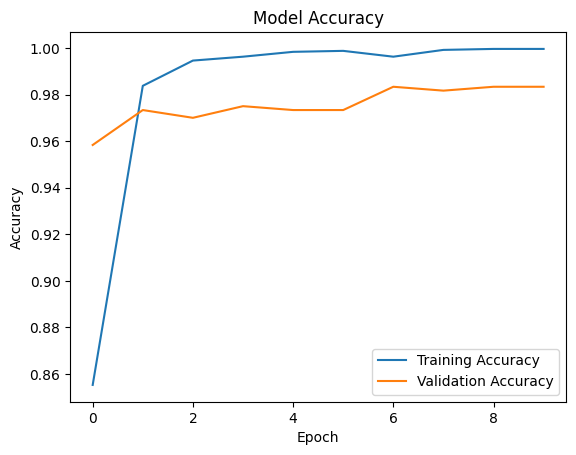

In [58]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [56]:
import os

os.makedirs("model", exist_ok=True)
model.save("model/spam_model.keras")


In [59]:
import pickle

# Save tokenizer
with open("model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)




In [60]:
model = tf.keras.models.load_model("model/spam_model.keras")
